# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [8]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [10]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [11]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [12]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [13]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [14]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [15]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [16]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [17]:
# cantidad de nulos para users
print('Cantidad de Nulos:','',users.isna().sum())
print('')
print('Promedio de nulos:','',users.isna().mean())

Cantidad de Nulos:  user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Promedio de nulos:  user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [18]:
# cantidad de nulos para usage
print('Cantidad de Nulos:','',usage.isna().sum())
print('')
print('Promedio de nulos:','',usage.isna().mean())

Cantidad de Nulos:  id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Promedio de nulos:  id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

-En la tabla de **users** encontre 2 columnas con nulos, **city con 469 nulos y un promedio del 11.7% y churn_date con 3534 nulos con un promedio del 88.3%**.

Para la columna **city** considero que es mejor imputar mientras que para **churn_date** es mejor ignorarla.



-En la tabla de **usage** encontre 3 columnas con nulos, **date con 50 nulos y un promedio del .12%, duration con 22076 nulos con un promedio del 55.1% y length con 17896 nulos y un promedio del 44.7%**.

Para la columna **date**, **length** y **duration** considero que es mejor ignorarlas ya que no impactan en las preguntas de negocio .


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
-  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [19]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene coherencia en relacion a su promedio y cuartiles. 
- La columna `age` tiene outliers que desvalancea el promedio.

In [20]:
# explorar columnas numéricas de usage
usage[['id','user_id','duration','length']].describe(
)

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` sus datos se ven coherentes con respecto a su promedio.  
- Las columnas `duration` y `length` se ven coherentes aunque duration pudiera tener algunos outliers que eleven su promedio.

In [21]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene 96 registrso con el signo`?`.
- La columna `plan` no presenta outliers.

In [22]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no presenta outliers


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- En la columna **age** y **city** encontre valores invalidos que voy a imputar con promedios y moda.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [23]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors= 'coerce')

In [24]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors= 'coerce')

In [25]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay 40 fechas mal registradas ya que solo deberian tener registros hasta el año 2024

In [26]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solo hay registros del 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- **Existen registros de años futuros, ignorar esos datos no afectarian nuestro analisis final.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [27]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [28]:

# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)


# Verificar cambios
users['city'].isin(['?']).sum()

0

In [29]:



# Marcar fechas futuras como NA para reg_date
fecha = users['reg_date'].dt.year > 2024
users.loc[fecha, 'reg_date'] = pd.NaT

# Verificar cambios

users['reg_date'].dt.year.value_counts()



2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [30]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [31]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Dejare los nulos tal y como estan ya que son del tipo MAR y si dependen de la columna TYPE

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [32]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage['call_minutes']= usage['duration'].where(usage['type']=='call',0)


# Agrupar información por usuario
usage_agg = (usage.groupby('user_id')
            .agg(
                total_text=('is_text','sum'),
                total_calls=('is_call', 'sum'),
                total_call_minutes=('call_minutes','sum'),
            )).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,total_text,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={
    'total_text':'cant_mensajes',
    'total_calls':'cant_llamadas',
    'total_call_minutes':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =pd.merge(usage_agg,users,on=['user_id'])
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,22.836934,48.138285
std,1154.898108,2.358416,2.144238,16.590213,17.691541
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.095000,33.000000
50%,12000.000000,5.000000,4.000000,19.740000,48.000000
75%,12999.500000,7.000000,6.000000,31.185000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [36]:
# Distribución porcentual del tipo de plan
dist_plan = (user_profile['plan']
               .value_counts(normalize=True)
               .rename_axis('plan')
               .reset_index(name='porcentaje'))

dist_plan['porcentaje'] = (dist_plan['porcentaje'] * 100).round(2)
dist_plan


,plan,porcentaje
0,Basico,64.87
1,Premium,35.13


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

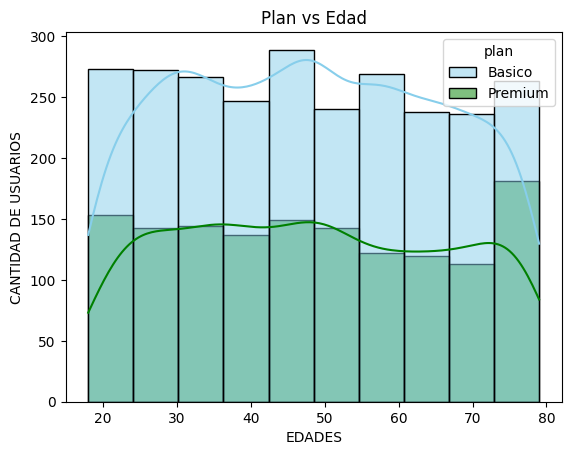

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x= 'age',hue='plan',bins=10,palette=['skyblue','green'],kde=True)
plt.xlabel('EDADES')
plt.ylabel('CANTIDAD DE USUARIOS')
plt.title('Plan vs Edad')
plt.show()

💡Insights: 
Dentro del plan premium hay menor cantidad de usuarios excepto por los usuarios de edades entre 75y 80 mientras qye para el plan basico hay mayor cantidad de usuarios y su concentracion esta entre las edades de 40 y 50 años. 

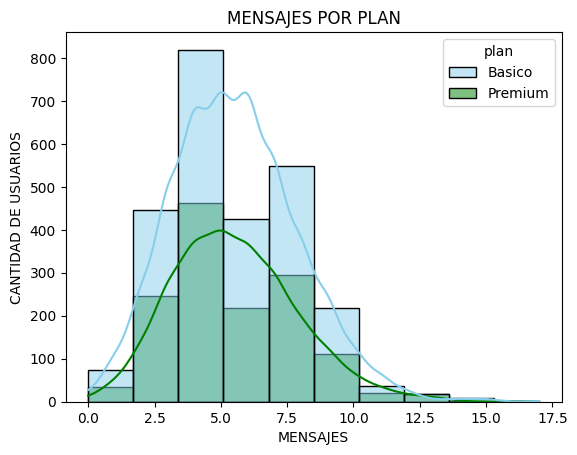

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x= 'cant_mensajes',hue='plan',bins=10,palette=['skyblue','green'],kde=True)
plt.xlabel('MENSAJES')
plt.ylabel('CANTIDAD DE USUARIOS')
plt.title('MENSAJES POR PLAN')
plt.show()

💡Insights: 
- Los usuaros del plan basico tienden a mandar mas mensajes que los usuarios del plan premium y ambos usuerios suelen mandar entre 3 y 5 mensajes.

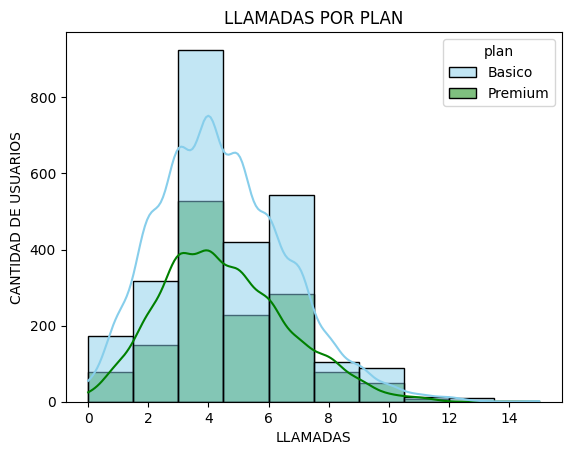

In [39]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x= 'cant_llamadas',hue='plan',bins=10,palette=['skyblue','green'],kde=True)
plt.xlabel('LLAMADAS')
plt.ylabel('CANTIDAD DE USUARIOS')
plt.title('LLAMADAS POR PLAN')
plt.show()


💡Insights: 
- La mayoria de usuarios realizan de 3 a 5 llamadas.

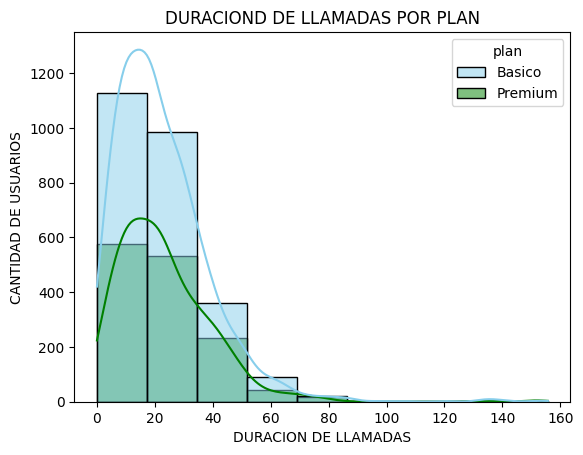

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x= 'cant_minutos_llamada',hue='plan',bins=9,palette=['skyblue','green'],kde=True)
plt.xlabel('DURACION DE LLAMADAS')
plt.ylabel('CANTIDAD DE USUARIOS')
plt.title('DURACIOND DE LLAMADAS POR PLAN')
plt.show()

💡Insights: 
- La mayoria de usuarios no realizan llamadas mayores a 30 min.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

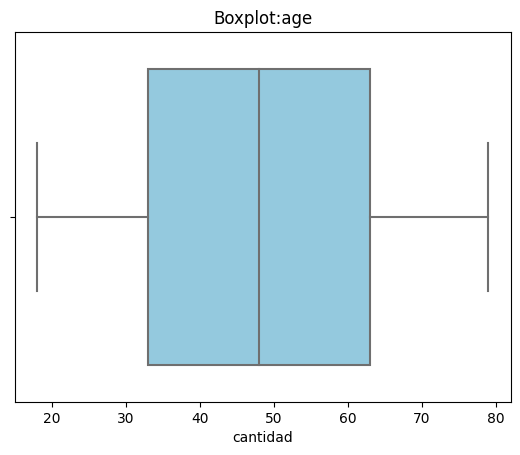

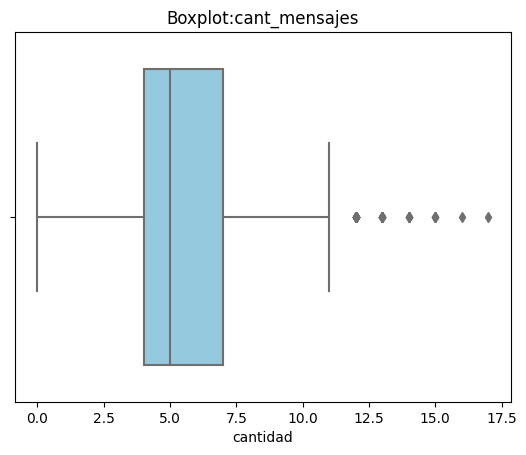

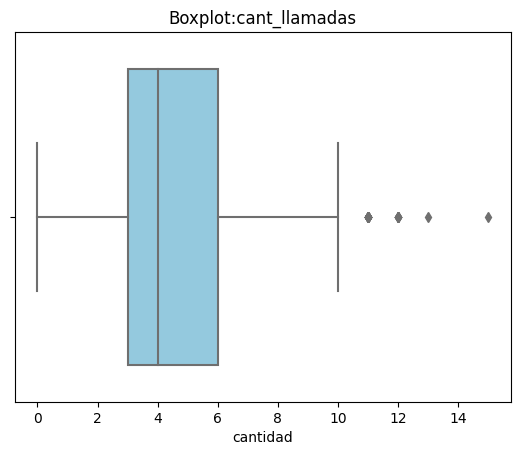

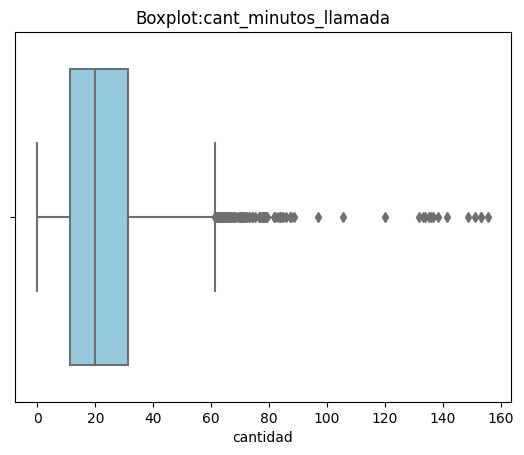

In [43]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot:{col}')
    plt.xlabel('cantidad')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes:Presenta 6 outliers
- cant_llamadas:Presenta 4 outliers
- cant_minutos_llamada: Es la columna con mayor outliers

In [58]:



# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    Extremo_inferior=Q1-1.5*IQR
    Extremo_superior=Q3+1.5*IQR

    print(col,'El extremo_inferior es:',Extremo_inferior,'El extremo superior es:',Extremo_superior)

    


cant_mensajes El extremo_inferior es: -0.5 El extremo superior es: 11.5
cant_llamadas El extremo_inferior es: -1.5 El extremo superior es: 10.5
cant_minutos_llamada El extremo_inferior es: -19.04 El extremo superior es: 61.31999999999999


In [59]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Mantendré los outliers ya que es muy poca la diferencia entre sus limites, su maximo y su minimo.
- cant_llamadas: mantener o no outliers, porqué?
- Mantendré sus outliers ya que no se alejan mucho de sus limites.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Los datos de cant_inutos_llamadas son los que mas varian con respecto a sus limites por eso no mantenerlos seria lo correcto.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [64]:
# Crear columna grupo_uso


def clasificar_uso(row):
    if row['cant_llamadas']<5 and row['cant_mensajes']<5:
        return 'Bajo uso'
    elif row['cant_llamadas']<10 and row['cant_mensajes']<10:
        return'Uso medio'
    else:
        return'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)





In [65]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [66]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age']<30:
        return 'Joven'
    elif row['age']<60:
        return'Adulto'
    else:
        return'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)


In [67]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

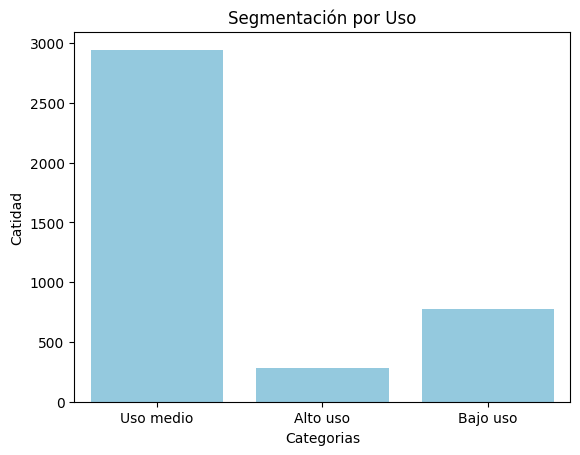

In [73]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile,x= 'grupo_uso',color='skyblue')
plt.title('Segmentación por Uso')
plt.xlabel('Categorias')
plt.ylabel('Catidad')

plt.show()


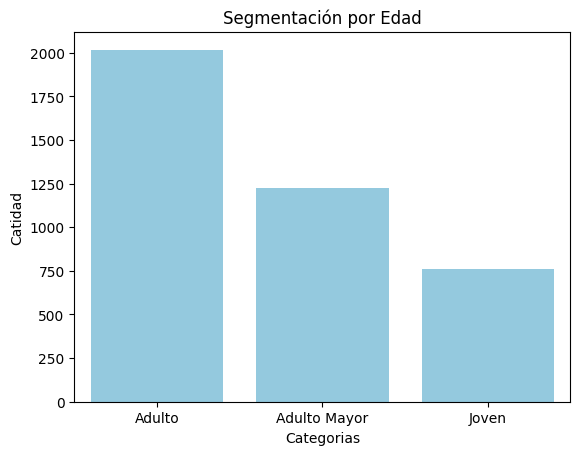

In [74]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x= 'grupo_edad',color='skyblue')
plt.title('Segmentación por Edad')
plt.xlabel('Categorias')
plt.ylabel('Catidad')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
**Los datos tenian varios outliers que representaban un reto poder limpiarlos ya que en la tabla de users encontre 2 columnas con nulos, city con 469 nulos y un promedio del 11.7% y churn_date con 3534 nulos con un promedio del 88.3%. 
En la tabla de usage encontre 3 columnas con nulos, date con 50 nulos y un promedio del .12%, duration con 22076 nulos con un promedio del 55.1% y length con 17896 nulos y un promedio del 44.7%.**

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
**Hice una segmentación de 3 tipos de clientes y edades encontrando que la mayoria son adultos con edades entre 30 y 60 y que el nivel de uso es mediano para la mayoria realizando menos de 10 llamadas y mensajes durante su plan.**
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
**Los segmentos mas valiosos serian el grupo adulto y el uso medio ya que ahi se encuentra la mayor parte de sus clientes.**
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
**Encontre extremos en la duracion de llamdas las cuales me resultan rasonables ya que son pocos clientes que tienen una duracion mayor a 30min.**

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

**Recomiendo que, si crean algun plan o quieren tener un mayor impacto en sus planes se enfoquen en el uso medio y que sea atractivo para los adulto ya que sus cleintes se concentran en esos dos segmentos, por otro lado tambien pueden hacer campañas que sean dirigidas para adultos mayores ya que es su segundo segmento mas fuerte.**

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la tabla 'users' encontre 2 columnas con nulos 'city' y 'churn_date' que ocupaban 11.7% y 88.3% respectivamente de sus datos registrados.
- En la tabla 'usage' encontre 2 columnas con nulos 'duration' y 'length' que abarcan un 55.1% y 44.7% respectivamente de sus datos registrados.
- Encontre registros de fechas imposibles siendo estas del año 2026 cuando el ultimo año registrado deberia ser 2024.
 

🔍 **Segmentos por Edad**
- Encontre 3 segmentos por edad siendo estos Joven para usuarios menores a 30 años, Adulto para usuarios mayores a 30 años pero menores a 60  años y Adulto mayor para mayores de 60.
- Encontre que la mayoria de usuarios estan en la segmentacion de Adultos mientras que la segmentacion Joven es la que menos usuarios contiene.


📊 **Segmentos por Nivel de Uso**
- Realicé 3 segmentos para el nivel de uso siendo estos 'bajo uso' con llamadas y mensajes menores a 5,'uso medio' con llamadas y mensajes mayores a 5 pero menores a 10 y 'alto uso'para los usuarios con llamadas y mensajes mayores a 10.
- Al realizar esta segmentacion entre que la mayoria de usuarios estan en la segmentacion de 'Uso medio' y la segmentacion con menos usuarios es la de 'Alto uso'


➡️ Esto sugiere que ...
Los segmentos mas valiosos para ConnectaTe deberian ser Adultos con un uso medio en su plan, ya que en estos se encuentran la mayoria de sus usuarios.

💡 **Recomendaciones**
- Recomiendo enfocar sus campañas en los segmentos de Adultos con uso medio en su plan para que no bajen su uso.
- Recominedo prestar atencion al segmento de Alto uso ya que pudieran realizar una campaña atractiva para que usuarios de medio uso puedan migrar de segmento.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`